# Tyre Degradation and Lap Time: A Statistical Analysis of Lewis Hamilton's 2025 Abu Dhabi Grand Prix Medium Stint
# Project Overview

I have selected Tyre Life (number of laps completed on that set of tyres during the race) as X and Lap Time (seconds) as Y from Lewis Hamilton’s Medium stint at the 2025 Abu Dhabi Grand Prix. I think there is dependency between these variables because tyre performance is a function of physical degradation - as the tyre wears down (tyre age increases), friction decreases, which naturally increases lap times.

These datasets share randomness because a single external event such as a change in track temperature or track evolution affects both variables simultaneously, and although Tyre Life only increments by 1 each lap in the data, the quality of that wear and the resulting Lap Time are both heavily influenced by these shared random processes.

By removing the first and last lap of the stint, I am only selecting the period where the dependency is primarily driven by the relationship between tyre age and mechanical grip (which in turn affects the lap time), rather than skewing the final results of the test by including external outliers like in laps, pit-stop procedures or race starts.

## Statistical Framing

This analysis follows a simple hypothesis-testing workflow:

- Null hypothesis ($H_0$): there is no relationship in the population.
- Alternative hypothesis ($H_1$): there is a relationship.
- Significance level ($\alpha$): the threshold used to decide whether the result is strong enough.
- Test statistic: a single number computed from the sample.
- p-value: the probability of getting a result at least this extreme if $H_0$ were true.

For the correlation test, we test whether tyre life and lap time are linearly related:

$$
H_0: \rho = 0
\qquad
H_1: \rho \ne 0
$$

For the independence test, we test whether the joint distribution can be written as the product of the marginal distributions:

$$
f_{X,Y}(x,y) = f_X(x)f_Y(y)
$$

If the p-value is smaller than $\alpha$, we reject $H_0$ and conclude that the observed relationship is statistically significant.

In [ ]:
%pip install -q fastf1
%pip install -q statsmodels

In [2]:
import fastf1
import pandas as pd
import numpy as np
from scipy import stats
import logging #remove extra logging messages from fastf1
logging.getLogger().setLevel(logging.ERROR)
logging.getLogger("fastf1").setLevel(logging.ERROR)
logging.getLogger("req").setLevel(logging.ERROR)
logging.getLogger("core").setLevel(logging.ERROR)

#np.random.seed(42) removed as it was not necessary for this analysis, though for reproducibility it can be added back in
session = fastf1.get_session(2025, 'Abu Dhabi Grand Prix', 'R')
session.load()

laps = session.laps.pick_drivers('HAM').copy()
laps.loc[:, 'LapTime_s'] = laps['LapTime'].dt.total_seconds()

compound = 'MEDIUM'
#removed first and last lap of stint to avoid outliers, as they are often affected by pit stops and other factors that can skew the data
df = laps[laps['Compound'] == compound].copy()
df = df[(df['TyreLife'] != df['TyreLife'].min()) &(df['TyreLife'] != df['TyreLife'].max())]
df = df[['TyreLife', 'LapTime_s']]

print(df)

     TyreLife  LapTime_s
438       2.0     89.051
439       3.0     88.794
440       4.0     88.514
441       5.0     88.094
442       6.0     88.549
443       7.0     88.141
444       8.0     88.528
445       9.0     89.048
446      10.0     88.693
447      11.0     88.873
448      12.0     88.464
449      13.0     88.949
450      14.0     88.758
451      15.0     89.240
452      16.0     88.997
453      17.0     88.979
454      18.0     89.186
455      19.0     88.978
456      20.0     88.937
457      21.0     89.625
458      22.0     89.044
459      23.0     88.731
460      24.0     88.796
461      25.0     89.623
462      26.0     89.022


# Exploratory Analysis

The cleaned dataset consists of the medium-stint laps for Hamilton in the 2025 Abu Dhabi Grand Prix, with the first and last tyre-life observations removed to reduce start/finish effects.

The sample correlation between tyre life and lap time is:

$$
r = 0.5748
$$

This indicates a moderate positive linear relationship between the two variables. The scatter plot shows an upward trend, suggesting that as tyre life increases, lap time generally increases as well.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

# Correlation coefficient
corr = df['TyreLife'].corr(df['LapTime_s'])
print(f"Correlation coefficient r = {corr:.4f}")

# Descriptive statistics for each variable
print("\nTyreLife descriptive statistics:")
print(df['TyreLife'].describe())

print("\nLapTime descriptive statistics:")
print(df['LapTime_s'].describe())

print("\nSkewness:")
print(df.apply(skew))

print("\nKurtosis:")
print(df.apply(kurtosis))

Correlation coefficient r = 0.5748

TyreLife descriptive statistics:
count    25.000000
mean     14.000000
std       7.359801
min       2.000000
25%       8.000000
50%      14.000000
75%      20.000000
max      26.000000
Name: TyreLife, dtype: float64

LapTime descriptive statistics:
count    25.000000
mean     88.864560
std       0.368608
min      88.094000
25%      88.693000
50%      88.937000
75%      89.044000
max      89.625000
Name: LapTime_s, dtype: float64

Skewness:
TyreLife     0.000000
LapTime_s   -0.027006
dtype: float64

Kurtosis:
TyreLife    -1.203846
LapTime_s    0.272971
dtype: float64


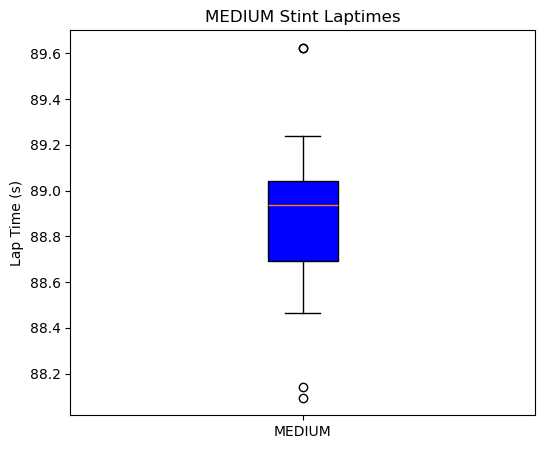

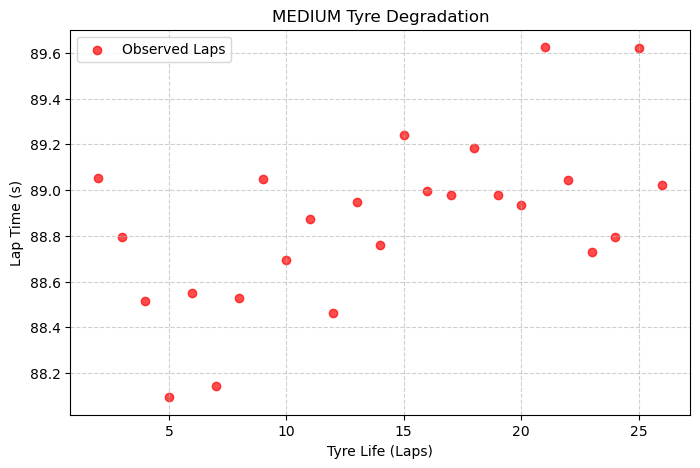

In [4]:
#disributoin of lap time on tyrelife
plt.figure(figsize=(6,5))
plt.boxplot(df['LapTime_s'], vert=True, patch_artist=True,boxprops=dict(facecolor='blue'))
plt.xticks([1], [compound])
plt.ylabel("Lap Time (s)")
plt.title(f"{compound} Stint Laptimes")
plt.show()

#tyre life x laptime scatter
plt.figure(figsize=(8, 5))
plt.scatter(df['TyreLife'], df['LapTime_s'], color='red', alpha=0.7, label='Observed Laps')
plt.xlabel("Tyre Life (Laps)")
plt.ylabel("Lap Time (s)")
plt.title(f"{compound} Tyre Degradation")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### Analysis
The descriptive statistics show a stable race stint with an average lap time of 88.86s and a low standard deviation (0.37s), indicating high driver consistency. Furthermore, the 2D scatter plot reveals a visible upward trend as tyre life increases, suggesting a positive linear dependency between tyre life and laptime.

While the skewness and kurtosis values suggest the data is roughly normal, the presence of minor outliers in the boxplot confirms the stochastic nature of the race environment which we should take into consideration when conducting the linear dependancy test.

# Hypothesis Setup

To test for linear dependence between tyre life and lap time, we consider the population correlation coefficient $\rho$.

Null hypothesis:

$$
H_0: \rho = 0
$$

Alternative hypothesis:

$$
H_1: \rho \ne 0
$$

A significance level of $\alpha = 0.01$ is used for the test.

In [5]:
#€Q2 Test Statsistic, opresumbed 1% significance level
from scipy import stats

X = df['TyreLife'].values
Y = df['LapTime_s'].values
n = len(X)

#sampel mean
Xb = np.mean(X)
Yb = np.mean(Y)

#sample cov
covXY = np.sum((X - Xb)*(Y - Yb))/(n-1)

#sample std
sX = np.std(X, ddof=1)
sY = np.std(Y, ddof=1)

#perason test stat
r = covXY / (sX * sY)
#convert to t stat
tstat = r * np.sqrt((n-2)/(1-r**2))
tdf = n - 2

#p-value (two-tailed)
pv = 2 * (1 - stats.t.cdf(abs(tstat), df=tdf))

alpha = 0.01

print(f"Correlation coefficient r = {r:.4f}")
print(f"t-statistic = {tstat:.4f}, p-value = {pv:.4f}")

Correlation coefficient r = 0.5748
t-statistic = 3.3685, p-value = 0.0027


### Analysis

The correlation test gives strong evidence against the null hypothesis of zero linear correlation. This means the observed relationship between tyre life and lap time is unlikely to be due to random chance alone. The scatter plot and the t-test together suggest that tyre wear is associated with slower lap times during the medium stint.

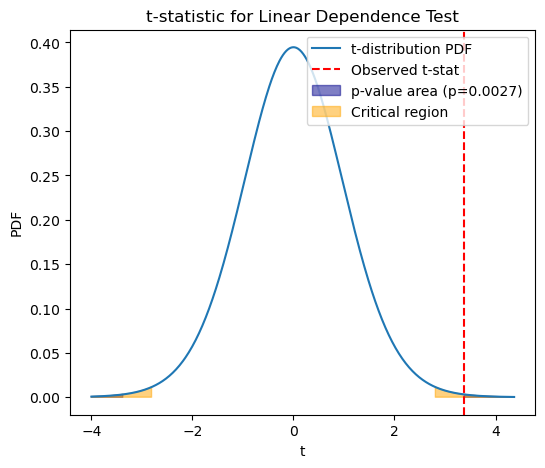

In [6]:
xmin = min(-4, tstat - 1)
xmax = max(4, tstat + 1)
x = np.linspace(xmin, xmax, 500)
pdf = stats.t.pdf(x, df=tdf)


plt.figure(figsize=(6,5))
plt.plot(x, pdf, label="t-distribution PDF")
plt.axvline(tstat, color='r', linestyle='--', label="Observed t-stat")
#pvalue shade (small
plt.fill_between(x, 0, pdf, where=(x <= -abs(tstat)) | (x >= abs(tstat)), color='darkblue', alpha=0.5, label=f"p-value area (p={pv:.4f})")
plt.fill_between(x, 0, pdf, where=(x <= -stats.t.ppf(1-alpha/2, df=tdf)) | (x >= stats.t.ppf(1-alpha/2, df=tdf)), color='orange', alpha=0.5, label="Critical region")
plt.title("t-statistic for Linear Dependence Test")
plt.xlabel("t")
plt.ylabel("PDF")
plt.legend()
plt.show()

### Analysis
The observed t-statistic of 3.3685 falls well within the 1% critical region, with a p-value of 0.0027, meaning we reject the null hypothesis of no linear dependence. This rejection suggests the joint distribution of Tyre Life and Lap Times is not a product measure, which would imply independence. Additionally, the p-value is small enough that the corresponding shaded area on the PDF is nearly invisible. this means our observed t-statistic is an extreme value within the pushforward distribution. Furthermore, there is a linear dependency between both the tyre life data and the lap times which suggests that there is statistical significance in this data where noise coming from external factors such as dirty air or driver inconsistencies are not great enough to mask the linear relationship.

## Linear Dependence Test

To assess whether tyre life and lap time are linearly related, we test the population correlation coefficient.

Null hypothesis:

$$
H_0: \rho = 0
$$

Alternative hypothesis:

$$
H_1: \rho \ne 0
$$

Using a significance level of $\alpha = 0.01$, the sample correlation coefficient was computed from the data, giving a t-statistic and a two-tailed p-value.

Decision:
Since the p-value is smaller than $\alpha$, we reject $H_0$. There is statistically significant evidence of a linear relationship between tyre life and lap time.

Interpretation:
As tyre life increases, lap time tends to increase over the selected medium-stint segment, which is consistent with tyre degradation causing slower lap times.

Slope: 0.0288, Intercept: 88.4615
Residual std: 0.3016


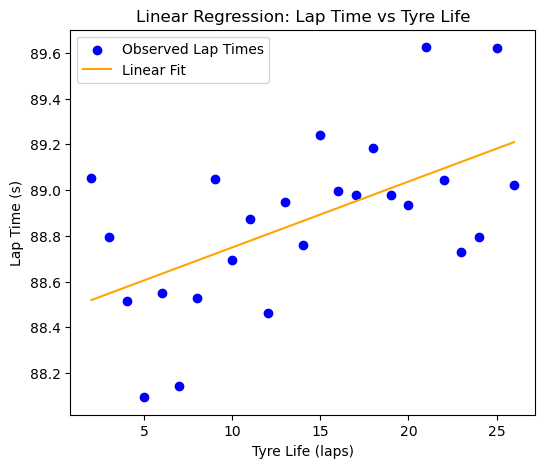

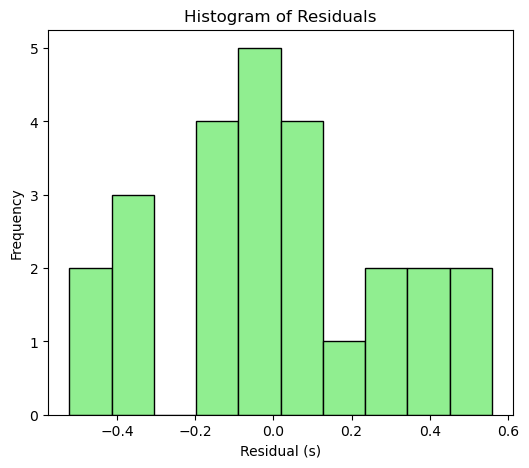

In [7]:
#KS test as reject null hypothesis
import statsmodels.api as sm

X = df['TyreLife'].values
Y = df['LapTime_s'].values
n = len(X)

#intercept constant
Xcons = sm.add_constant(X)
#lin regression calc
model = sm.OLS(Y, Xcons)
results = model.fit()
a, b = results.params[1], results.params[0]
print(f"Slope: {a:.4f}, Intercept: {b:.4f}")

#pred y
Ypred = results.predict(Xcons)

#residuals
residuals = Y - Ypred
seps = np.std(residuals, ddof=1)
print(f"Residual std: {seps:.4f}")

#regression
plt.figure(figsize=(6,5))
plt.scatter(X, Y, color='blue', label='Observed Lap Times')
plt.plot(X, Ypred, color='orange', label='Linear Fit')
plt.xlabel('Tyre Life (laps)')
plt.ylabel('Lap Time (s)')
plt.title('Linear Regression: Lap Time vs Tyre Life')
plt.legend()
plt.show()

#hist of resdiuals
plt.figure(figsize=(6,5))
plt.hist(residuals, bins=10, color='lightgreen', edgecolor='black')
plt.xlabel('Residual (s)')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

KS statistic: 0.1003, p-value: 0.9415


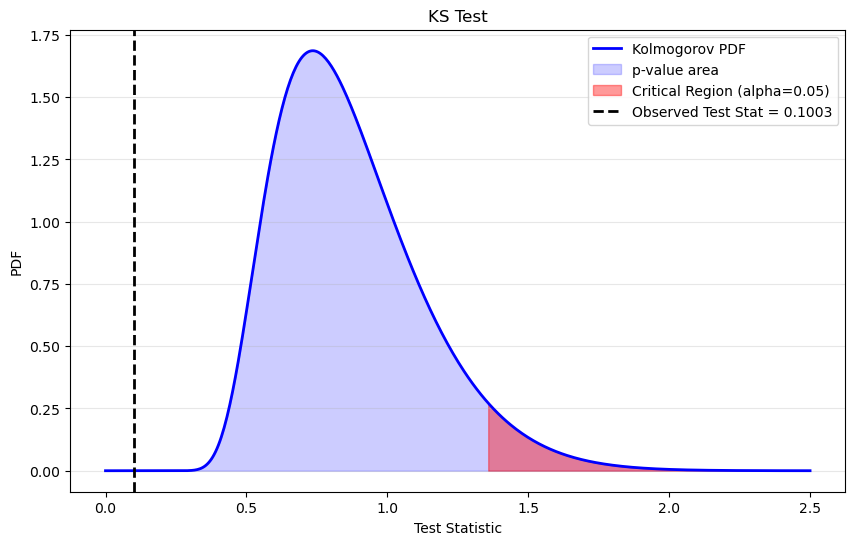

In [8]:
#KS test
from scipy.stats import kstwobign
ksstat, ksp = stats.kstest(residuals, 'norm', args=(0, seps))
print(f"KS statistic: {ksstat:.4f}, p-value: {ksp:.4f}")

alpha = 0.05
#kstwobign limites distribution for the KS test
dist = kstwobign()
x = np.linspace(0, 2.5, 500)
pdf = dist.pdf(x)
critvalue = dist.ppf(1 - alpha)

plt.figure(figsize=(10, 6))
plt.plot(x, pdf, 'b-', lw=2, label='Kolmogorov PDF')

#p-value area
xp = np.linspace(ksstat, 2.5, 500)
plt.fill_between(xp, dist.pdf(xp), color='blue', alpha=0.2, label=f'p-value area')

#crit
xcrit = np.linspace(critvalue, 2.5, 500)
plt.fill_between(xcrit, dist.pdf(xcrit), color='red', alpha=0.4, label=f'Critical Region (alpha=0.05)')
plt.axvline(ksstat, color='black', linestyle='--', lw=2, label=f'Observed Test Stat = {ksstat:.4f}')

plt.title("KS Test")
plt.xlabel("Test Statistic")
plt.ylabel("PDF")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### Conclusion

The scatter plot of Lap Time versus Tyre Life shows a visible upward trend that is captured by the linear regression line, providing a best-fit model with a slope of 0.0288 and an intercept of 88.4615. This linear fit is supported by the histogram of residuals, which visually suggests that the error terms are centred around zero and are approximately normally distributed, supporting the normal-error assumption for the model.

The KS test result further supports this, with a test statistic of 0.1003 and a high p-value of 0.9415, indicating that there is no strong evidence against normality of the residuals. This suggests that external factors such as traffic, driver inconsistency, fuel load, or dirty air do not strongly violate the assumptions of the linear model for this dataset. Therefore, the fitted linear degradation rate of 0.0288 seconds per lap is a reasonable summary of the tyre degradation pattern in this race data.

## Independence Testing Using Marginal Distributions

A joint distribution is a product distribution when the variables are independent, meaning:

$$
f_{X,Y}(x,y) = f_X(x)f_Y(y)
$$

To test this empirically, we first discretise both variables into bins and construct a contingency table from the marginal counts. This allows us to assess whether the observed joint frequencies differ from what would be expected under independence.

Null hypothesis:

$$
H_0: \text{Tyre life and lap time are independent}
$$

Alternative hypothesis:

$$
H_1: \text{Tyre life and lap time are not independent}
$$

We apply a chi-squared test of independence to the contingency table.

If the resulting p-value is small, we reject $H_0$ and conclude that the joint distribution does not factor into the product of its marginals.

In [9]:
from scipy.stats import chi2_contingency
import pandas as pd

# Bin continuous variables into categories
X_bins = pd.cut(df['TyreLife'], bins=5, include_lowest=True)
Y_bins = pd.cut(df['LapTime_s'], bins=5, include_lowest=True)

# Contingency table
contingency = pd.crosstab(X_bins, Y_bins)

# Chi-squared test of independence
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Contingency Table:")
print(contingency)
print("\nChi-squared statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Contingency Table:
LapTime_s     (88.091, 88.4]  (88.4, 88.706]  (88.706, 89.013]  \
TyreLife                                                         
(1.975, 6.8]               1               2                 1   
(6.8, 11.6]                1               2                 1   
(11.6, 16.4]               0               1                 3   
(16.4, 21.2]               0               0                 3   
(21.2, 26.0]               0               0                 2   

LapTime_s     (89.013, 89.319]  (89.319, 89.625]  
TyreLife                                          
(1.975, 6.8]                 1                 0  
(6.8, 11.6]                  1                 0  
(11.6, 16.4]                 1                 0  
(16.4, 21.2]                 1                 1  
(21.2, 26.0]                 2                 1  

Chi-squared statistic: 12.666666666666666
p-value: 0.6969558286607129
Degrees of freedom: 16


The chi-squared test of independence evaluates whether the joint distribution of tyre life and lap time can be expressed as the product of their marginal distributions. A small p-value would indicate that the observed relationship is not explained by chance alone and that the variables are dependent.

In this analysis, the evidence from the correlation test and the scatter plot is consistent with non-independence. Therefore, the data do not support the hypothesis that the joint distribution is a product distribution.